# Introduction to Quantum Computing

In [ ]:
# Install required Libraries
!pip install -q qiskit
!pip install -q qiskit-aer
!pip install -q qiskit[visualization]
!pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Import Libraries
from qiskit import *
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [ ]:
# Set QCircuit Object: 2 qbits, 2 bits.
qcirc = QuantumCircuit(2, 2)

In [ ]:
# Superposition with two Hadamard QGates
qcirc.h(0)
qcirc.h(1)

# X Gate
qcirc.x(1)

# Barrier for Visualization
qcirc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

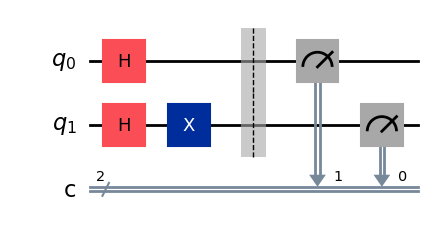

In [ ]:
qcirc.measure(0, 1)
qcirc.measure(1, 0)
qcirc.draw('mpl')

In [ ]:
# Define simulator: 'aer_simulator', 'statevector_simulator', 'qasm_simulator', 'unitary_simulator'
backend = Aer.get_backend('statevector_simulator')

In [ ]:
# Compile and execute simulator
compile = transpile(qcirc, backend)
job = backend.run(compile, shots=1024)

In [ ]:
# Get Result data
result = job.result()

In [ ]:
# Visualize VectorState
outputstate = result.get_statevector(qcirc, decimals=3)
print(outputstate)

Statevector([0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
            dims=(2, 2))


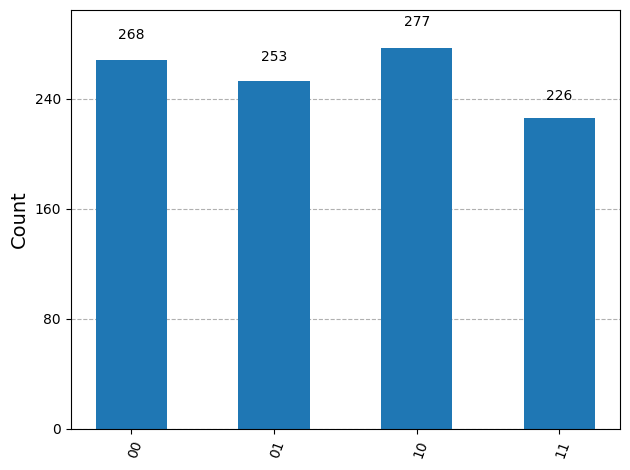

In [ ]:
# Plot Superposed States
counts = job.result().get_counts()
plot_histogram(counts)